In [1]:
import numpy as np
from scipy.stats import landau

import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from diff_random.distributions import Landau_SG

In [2]:
loc_0, scale_0 = 2.0, 3.0
loc_1, scale_1 = 1.0, 4.0

In [3]:
numpy_seed = 0
rng = np.random.Generator(np.random.PCG64DXSM(numpy_seed))

jax_seed = 0
key = jax.random.key(jax_seed)

In [4]:
N = 1_000_000
scipy_samples_0 = landau.rvs(loc=loc_0, scale=scale_0, size=(N,), random_state=rng)
scipy_samples_1 = landau.rvs(loc=loc_1, scale=scale_1, size=(N,), random_state=rng)

In [5]:
jax_samples_0 = Landau_SG(loc=loc_0, scale=scale_0).generate(key, batch_shape=(N,))
jax_samples_1 = Landau_SG(loc=loc_1, scale=scale_1).generate(key, batch_shape=(N,))

log_w_0_to_1 = Landau_SG(loc=loc_0, scale=scale_0).reweight(
    jax_samples_0, loc_1, scale_1
)
log_w_1_to_0 = Landau_SG(loc=loc_1, scale=scale_1).reweight(
    jax_samples_1, loc_0, scale_0
)

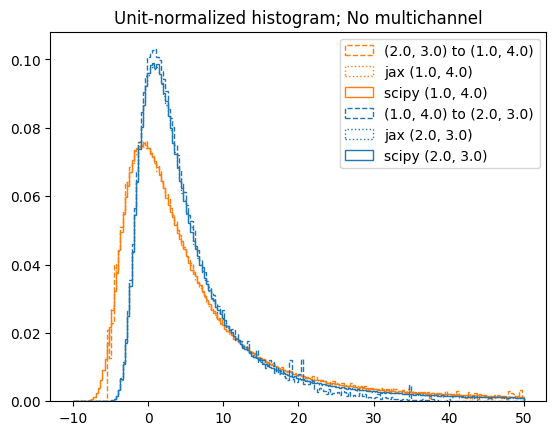

In [6]:
fig, ax = plt.subplots()

ax.hist(
    [
        scipy_samples_0,
        jax_samples_0[0],
        jax_samples_1[0],
        scipy_samples_1,
        jax_samples_1[0],
        jax_samples_0[0],
    ],
    weights=[
        jnp.ones(N),
        jnp.ones(N),
        jnp.exp(log_w_1_to_0),
        jnp.ones(N),
        jnp.ones(N),
        jnp.exp(log_w_0_to_1),
    ],
    label=[
        f"scipy {(loc_0, scale_0)}",
        f"jax {(loc_0, scale_0)}",
        f"{(loc_1, scale_1)} to {(loc_0, scale_0)}",
        f"scipy {(loc_1, scale_1)}",
        f"jax {(loc_1, scale_1)}",
        f"{(loc_0, scale_0)} to {(loc_1, scale_1)}",
    ],
    histtype="step",
    linestyle=["solid", "dotted", "dashed", "solid", "dotted", "dashed"],
    color=["C0", "C0", "C0", "C1", "C1", "C1"],
    range=(-10, 50),
    bins=200,
    density=True,
)
ax.legend()
plt.title("Unit-normalized histogram; No multichannel")

None

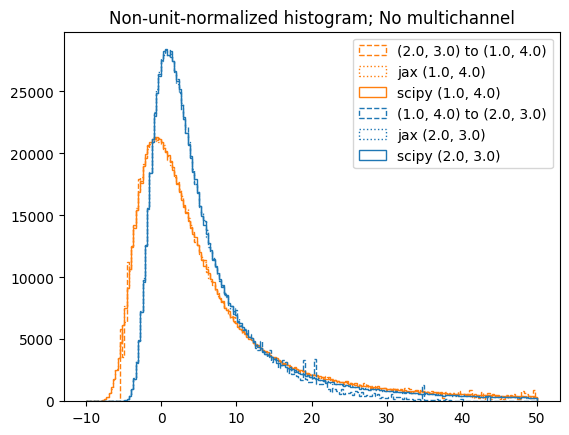

In [7]:
fig, ax = plt.subplots()

ax.hist(
    [
        scipy_samples_0,
        jax_samples_0[0],
        jax_samples_1[0],
        scipy_samples_1,
        jax_samples_1[0],
        jax_samples_0[0],
    ],
    weights=[
        jnp.ones(N),
        jnp.ones(N),
        jnp.exp(log_w_1_to_0),
        jnp.ones(N),
        jnp.ones(N),
        jnp.exp(log_w_0_to_1),
    ],
    label=[
        f"scipy {(loc_0, scale_0)}",
        f"jax {(loc_0, scale_0)}",
        f"{(loc_1, scale_1)} to {(loc_0, scale_0)}",
        f"scipy {(loc_1, scale_1)}",
        f"jax {(loc_1, scale_1)}",
        f"{(loc_0, scale_0)} to {(loc_1, scale_1)}",
    ],
    histtype="step",
    linestyle=["solid", "dotted", "dashed", "solid", "dotted", "dashed"],
    color=["C0", "C0", "C0", "C1", "C1", "C1"],
    range=(-10, 50),
    bins=200,
    density=False,
)
ax.legend()
plt.title("Non-unit-normalized histogram; No multichannel")

None